# 종합 다변량 분석: 기상청 + 센서 전체 데이터 통합 시각화
1. 평행 좌표계  2. 방사형 차트  3. 이동 평균 기온 추세 (전날 16:00~당일 10:00)

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from pathlib import Path
from datetime import datetime, timedelta
import json as json_mod
import warnings

warnings.filterwarnings('ignore')
plt.rcdefaults()

df = pd.read_csv('measurements.csv')
df['distance_cm_avg'] = df['distance_cm_avg'].replace(-1.0, np.nan)
df['ldr_avg'] = df['ldr_avg'].replace(-1.0, np.nan)
df = df[df['black_ice_status'].isin(['occurred', 'not_occurred'])].copy()

def get_kma_overnight(date_str):
    wf = Path(f'weather/kma_data_{date_str}.json')
    if not wf.exists(): return np.nan, np.nan
    with open(wf, 'r', encoding='utf-8') as f:
        wj = json_mod.load(f)
    temps, hums = [], []
    for pt in wj['collected_data']:
        for line in pt['data'].split('\n'):
            if line.startswith('#') or not line.strip(): continue
            parts = [p.strip() for p in line.split(',')]
            if len(parts) >= 3:
                dt = datetime.strptime(parts[0], '%Y%m%d%H%M')
                if 0 <= dt.hour <= 8:
                    temps.append(float(parts[1]))
                    hums.append(float(parts[2]))
    return (min(temps) if temps else np.nan, max(hums) if hums else np.nan)

def load_kma_ts(date_str):
    wf = Path(f'weather/kma_data_{date_str}.json')
    if not wf.exists(): return pd.DataFrame()
    with open(wf, 'r', encoding='utf-8') as f:
        wj = json_mod.load(f)
    recs = []
    for pt in wj['collected_data']:
        for line in pt['data'].split('\n'):
            if line.startswith('#') or not line.strip(): continue
            parts = [p.strip() for p in line.split(',')]
            if len(parts) >= 2:
                recs.append({'datetime': datetime.strptime(parts[0], '%Y%m%d%H%M'), 'ta': float(parts[1])})
    if not recs: return pd.DataFrame()
    return pd.DataFrame(recs).groupby('datetime').mean().reset_index().sort_values('datetime')

def load_kma_prev_afternoon(date_str):
    target = datetime.strptime(date_str, '%Y-%m-%d')
    prev_str = (target - timedelta(days=1)).strftime('%Y-%m-%d')
    base = target - timedelta(hours=8)
    df_prev = load_kma_ts(prev_str)
    if not df_prev.empty:
        df_prev = df_prev[df_prev['datetime'].dt.hour >= 16].copy()
    df_cur = load_kma_ts(date_str)
    if not df_cur.empty:
        df_cur = df_cur[df_cur['datetime'].dt.hour <= 10].copy()
    combined = pd.concat([df_prev, df_cur], ignore_index=True).sort_values('datetime')
    if combined.empty: return pd.DataFrame()
    combined['elapsed'] = (combined['datetime'] - base).dt.total_seconds() / 3600.0
    combined['ta_ma'] = combined['ta'].rolling(window=4, center=True).mean()
    return combined

kma_cache = {}
for d in df['date'].unique():
    kma_cache[d] = get_kma_overnight(d)
df['kma_min_temp'] = df['date'].map(lambda d: kma_cache[d][0])
df['kma_max_humidity'] = df['date'].map(lambda d: kma_cache[d][1])

print(f'Occurred: {(df["black_ice_status"]=="occurred").sum()} | Not Occurred: {(df["black_ice_status"]=="not_occurred").sum()}')

Occurred: 4 | Not Occurred: 29


---
## 1. 평행 좌표계
📖 [평행좌표계 (한국어)](https://ko.wikipedia.org/wiki/%ED%8F%89%ED%96%89_%EC%A2%8C%ED%91%9C%EA%B3%84)

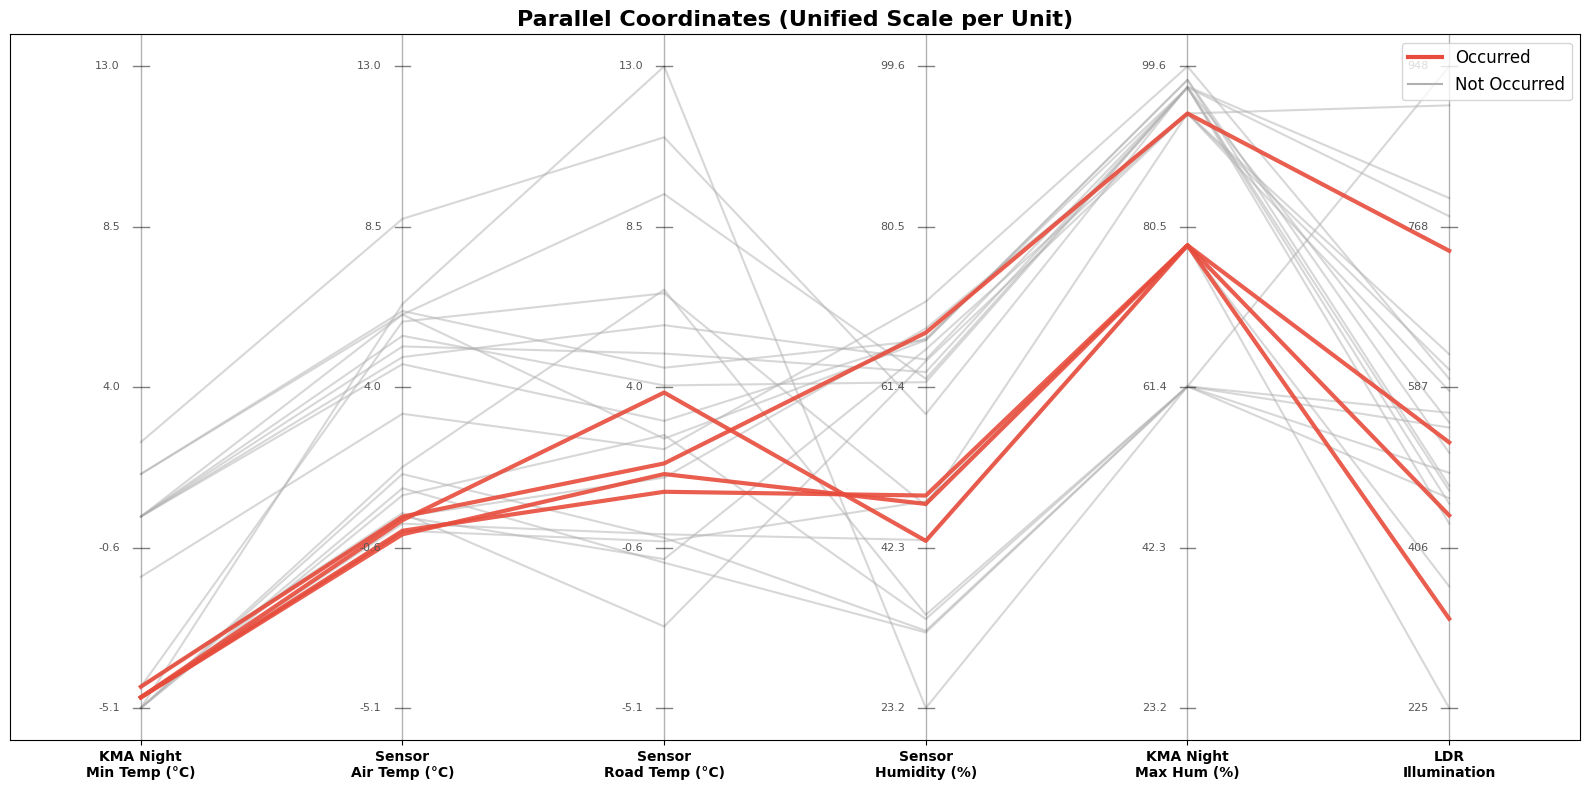

In [6]:
features = ['kma_min_temp', 'temperature', 'road_surface_temp', 'humidity', 'kma_max_humidity', 'ldr_avg']
labels_pc = ['KMA Night\nMin Temp (\u00b0C)', 'Sensor\nAir Temp (\u00b0C)', 'Sensor\nRoad Temp (\u00b0C)', 'Sensor\nHumidity (%)', 'KMA Night\nMax Hum (%)', 'LDR\nIllumination']
df_plot = df[features + ['black_ice_status']].dropna().copy()
tc = ['kma_min_temp', 'temperature', 'road_surface_temp']
t_min, t_max = df_plot[tc].min().min(), df_plot[tc].max().max()
hc = ['humidity', 'kma_max_humidity']
h_min, h_max = df_plot[hc].min().min(), df_plot[hc].max().max()
a_min, a_max = {}, {}
for f in features:
    if f in tc: a_min[f], a_max[f] = t_min, t_max
    elif f in hc: a_min[f], a_max[f] = h_min, h_max
    else: a_min[f], a_max[f] = df_plot[f].min(), df_plot[f].max()
df_n = df_plot[features].copy()
for f in features:
    rng = a_max[f] - a_min[f]
    df_n[f] = 0.5 if rng == 0 else (df_n[f] - a_min[f]) / rng
df_n['s'] = df_plot['black_ice_status'].values
fig, ax = plt.subplots(figsize=(16, 8))
x_pos = np.arange(len(features))
for _, row in df_n[df_n['s']=='not_occurred'].iterrows():
    ax.plot(x_pos, [row[f] for f in features], color='#b0b0b0', alpha=0.5, linewidth=1.5, zorder=1)
for _, row in df_n[df_n['s']=='occurred'].iterrows():
    ax.plot(x_pos, [row[f] for f in features], color='#e74c3c', alpha=0.9, linewidth=3, zorder=3)
for i, feat in enumerate(features):
    ax.axvline(x=i, color='black', linewidth=1, alpha=0.3)
    for tv, tp in zip(np.linspace(a_min[feat], a_max[feat], 5), np.linspace(0, 1, 5)):
        ax.plot([i-0.03, i+0.03], [tp, tp], color='black', linewidth=1, alpha=0.5)
        fmt = f'{tv:.1f}' if abs(tv) < 100 else f'{tv:.0f}'
        ax.text(i-0.08, tp, fmt, ha='right', va='center', fontsize=8, color='#555')
ax.set_xlim(-0.5, len(features)-0.5); ax.set_ylim(-0.05, 1.05)
ax.set_xticks(x_pos); ax.set_xticklabels(labels_pc, fontsize=10, weight='bold')
ax.set_yticks([])
ax.set_title('Parallel Coordinates (Unified Scale per Unit)', fontsize=16, weight='bold')
ax.legend(handles=[mlines.Line2D([0],[0], color='#e74c3c', linewidth=3, label='Occurred'), mlines.Line2D([0],[0], color='#b0b0b0', linewidth=1.5, label='Not Occurred')], loc='upper right', fontsize=12)
ax.grid(False); plt.tight_layout(); plt.show()

---
## 2. 방사형 차트
📖 [방사형 차트 (한국어)](https://ko.wikipedia.org/wiki/%EB%B0%A9%EC%82%AC%ED%98%95_%EC%B0%A8%ED%8A%B8)

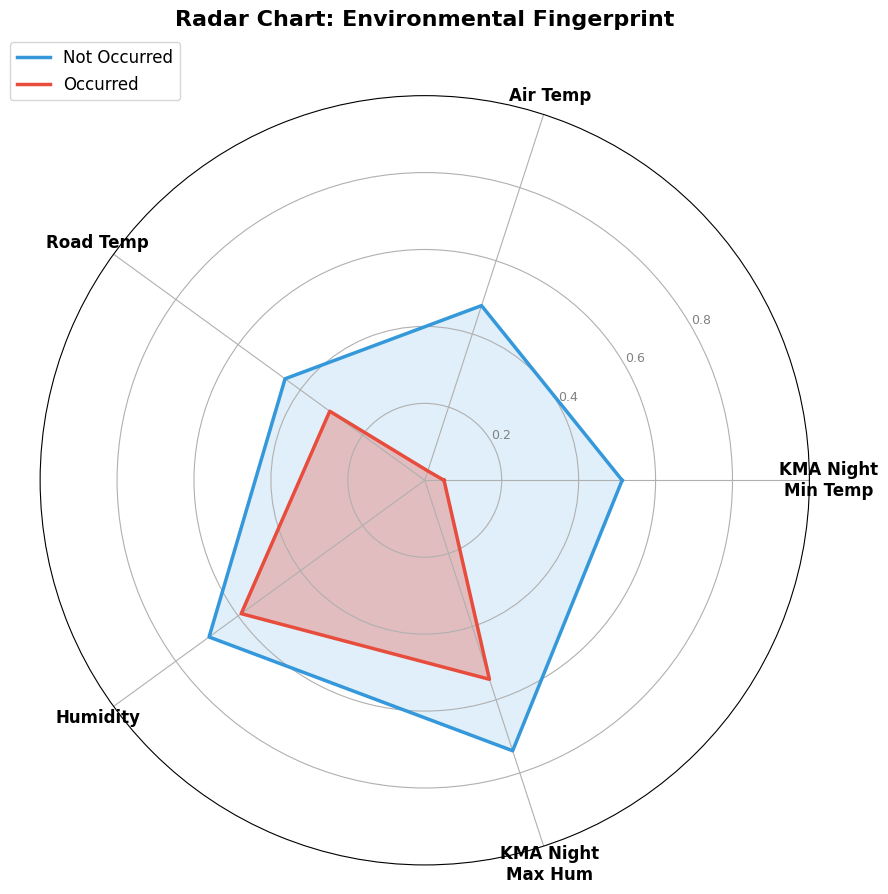

In [7]:
rf = ['kma_min_temp', 'temperature', 'road_surface_temp', 'humidity', 'kma_max_humidity']
df_r = df[rf + ['black_ice_status']].dropna()
df_m = df_r.groupby('black_ice_status')[rf].mean()
for f in rf:
    mn, mx = df_r[f].min(), df_r[f].max()
    df_m[f] = (df_m[f]-mn)/(mx-mn) if mx!=mn else 0.5
cats = ['KMA Night\nMin Temp', 'Air Temp', 'Road Temp', 'Humidity', 'KMA Night\nMax Hum']
N = len(cats)
ang = [n/float(N)*2*np.pi for n in range(N)] + [0]
fig, ax = plt.subplots(figsize=(9,9), subplot_kw=dict(polar=True))
v_n = df_m.loc['not_occurred'].values.flatten().tolist()+[df_m.loc['not_occurred'].values[0]]
ax.plot(ang, v_n, color='#3498db', linewidth=2.5, label='Not Occurred')
ax.fill(ang, v_n, color='#3498db', alpha=0.15)
v_o = df_m.loc['occurred'].values.flatten().tolist()+[df_m.loc['occurred'].values[0]]
ax.plot(ang, v_o, color='#e74c3c', linewidth=2.5, label='Occurred')
ax.fill(ang, v_o, color='#e74c3c', alpha=0.3)
ax.set_xticks(ang[:-1]); ax.set_xticklabels(cats, fontsize=12, weight='bold')
ax.set_rlabel_position(30)
ax.set_yticks([0.2,0.4,0.6,0.8]); ax.set_yticklabels(['0.2','0.4','0.6','0.8'], color='grey', size=9)
ax.set_ylim(0,1)
ax.set_title('Radar Chart: Environmental Fingerprint', size=16, weight='bold', y=1.08)
ax.legend(loc='upper left', bbox_to_anchor=(-0.05, 1.08), fontsize=12)
plt.tight_layout(); plt.show()

---
## 3. KMA 기온 추세 + 센서 실측값 (전날 16:00 ~ 당일 10:00)
모든 (날짜 × 위치) 조합의 KMA 추세선을 개별로 그립니다. 발생/미발생 여부는 각 위치별 상태를 기준으로 색상이 결정됩니다.
추세선 위에 센서 실측값(대기온도, 노면온도)을 마커로 오버레이합니다.

📖 [이동 평균 (한국어)](https://ko.wikipedia.org/wiki/%EC%9D%B4%EB%8F%99_%ED%8F%89%EA%B7%A0)

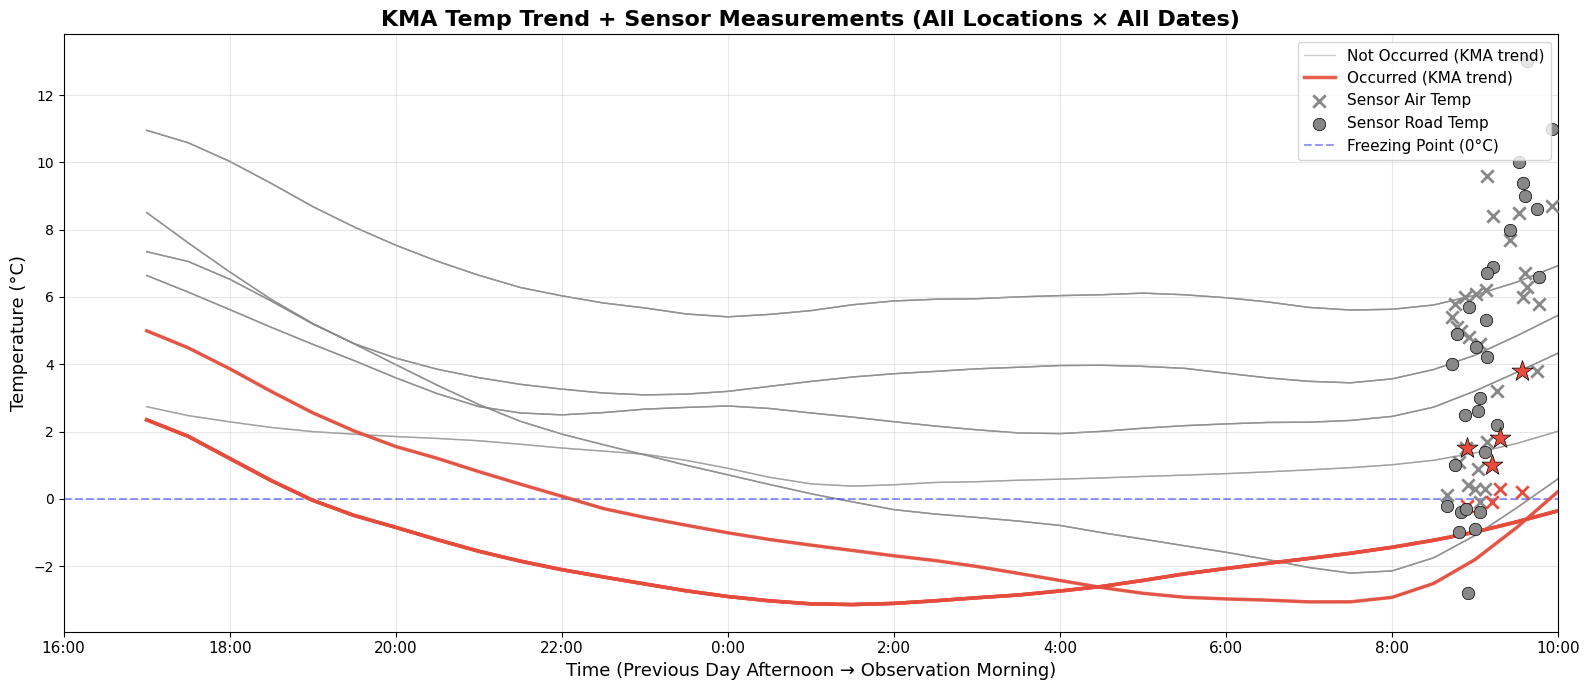

In [8]:
fig, ax = plt.subplots(figsize=(16, 7))
drawn = {'occ': False, 'not': False}

def to_elapsed(measured_at_str, date_str):
    target = datetime.strptime(date_str, '%Y-%m-%d')
    base = target - timedelta(hours=8)
    t = pd.to_datetime(measured_at_str).to_pydatetime().replace(tzinfo=None)
    return (t - base).total_seconds() / 3600.0

# 미발생 KMA 추세선 (배경)
for _, row in df[df['black_ice_status']=='not_occurred'].iterrows():
    df_kma = load_kma_prev_afternoon(row['date'])
    if df_kma.empty: continue
    lbl = 'Not Occurred (KMA trend)' if not drawn['not'] else ''
    ax.plot(df_kma['elapsed'], df_kma['ta_ma'], color='#888888', linewidth=1.0, alpha=0.4, zorder=1, label=lbl)
    drawn['not'] = True

# 발생 KMA 추세선 (전면)
for _, row in df[df['black_ice_status']=='occurred'].iterrows():
    df_kma = load_kma_prev_afternoon(row['date'])
    if df_kma.empty: continue
    lbl = 'Occurred (KMA trend)' if not drawn['occ'] else ''
    ax.plot(df_kma['elapsed'], df_kma['ta_ma'], color='#e74c3c', linewidth=2.5, alpha=0.9, zorder=3, label=lbl)
    drawn['occ'] = True

# 센서 실측값 오버레이
lbl_air, lbl_road = True, True
for _, row in df.iterrows():
    el = to_elapsed(row['measured_at'], row['date'])
    c = '#e74c3c' if row['black_ice_status']=='occurred' else '#888888'
    z = 5 if row['black_ice_status']=='occurred' else 4
    ax.scatter(el, row['temperature'], marker='x', color=c, s=80, linewidths=2, zorder=z, label='Sensor Air Temp' if lbl_air else '')
    lbl_air = False
    mk = '*' if row['black_ice_status']=='occurred' else 'o'
    sz = 250 if row['black_ice_status']=='occurred' else 80
    ax.scatter(el, row['road_surface_temp'], marker=mk, color=c, s=sz, edgecolors='black', linewidths=0.5, zorder=z+1, label='Sensor Road Temp' if lbl_road else '')
    lbl_road = False

ax.axhline(0, color='blue', linestyle='--', alpha=0.4, linewidth=1.5, label='Freezing Point (0\u00b0C)')
ax.set_xlim(0, 18)
ax.set_xticks([0,2,4,6,8,10,12,14,16,18])
ax.set_xticklabels(['16:00','18:00','20:00','22:00','0:00','2:00','4:00','6:00','8:00','10:00'], fontsize=11)
ax.set_xlabel('Time (Previous Day Afternoon \u2192 Observation Morning)', fontsize=13)
ax.set_ylabel('Temperature (\u00b0C)', fontsize=13)
ax.set_title('KMA Temp Trend + Sensor Measurements (All Locations \u00d7 All Dates)', fontsize=16, weight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## 핵심 인사이트
* **평행 좌표계**: 발생(빨강) 선은 KMA Night Min Temp에서 바닥을 찍고 Road Temp에서 급등 — 온도 역전 패턴.
* **이동 평균 추세**: 발생한 날(빨강)은 전날 오후부터 아침까지 **장시간 0°C 이하에 머물렀고**, 미발생 날(회색)은 0°C 위이거나 영하 체류 시간이 짧았습니다.
* **센서 실측값 오버레이**: KMA 추세선 위에 실제 측정된 대기온도(×)와 노면온도(●/★)가 표시되어, KMA 광역 데이터와 국지적 센서 데이터의 관계를 직접 확인할 수 있습니다.